# Computer Vision

(Date - 18/May/2026)

In [192]:
import torch
from torchmetrics import ConfusionMatrix
from torchmetrics import Accuracy
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from timeit import default_timer as Timer
from tqdm.auto import tqdm
import functools
import pandas as pd
import random
import mlxtend # The version should be 0.19 or higher
from mlxtend.plotting import plot_confusion_matrix
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
tqdm = functools.partial(tqdm, bar_format="{l_bar}\033[32m{bar:50}\033[0m{r_bar}")
print(f"PyTorch version : {torch.__version__}\ntorch.vision version : {torchvision.__version__}")

PyTorch version : 2.10.0+cpu
torch.vision version : 0.25.0+cpu


## 1. Getting a dataset

(Date - 19/May/2026)

In [2]:
train_data = datasets.FashionMNIST(
    root="data", # Where to download our data to
    train=True, # Do we want the training dataset?
    download=True, # Do we want to download yes/no?
    transform=torchvision.transforms.ToTensor(), # How do we want to transform the dataset?
    target_transform=None # How do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data", # Where to download our data to
    train=False, # Do we want the training dataset?
    download=True, # Do we want to download yes/no?
    transform=torchvision.transforms.ToTensor(), # How do we want to transform the dataset?
    target_transform=None
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

### 1.1 Checking input and output shapes

In [8]:
print(f"Image shape : {image.shape} -> [color channels, height, width]")
print(f"Image label : {class_names[label]}")

Image shape : torch.Size([1, 28, 28]) -> [color channels, height, width]
Image label : Ankle boot


### 1.2 Visualizing our data (images)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

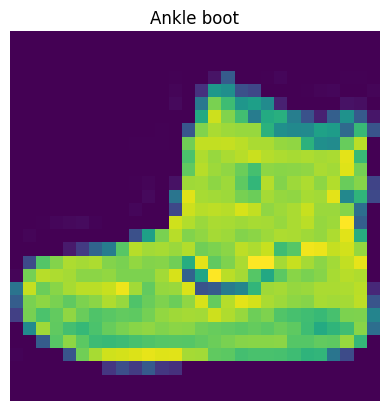

In [9]:
plt.imshow(image.squeeze())
plt.title(class_names[label])
plt.axis(False)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

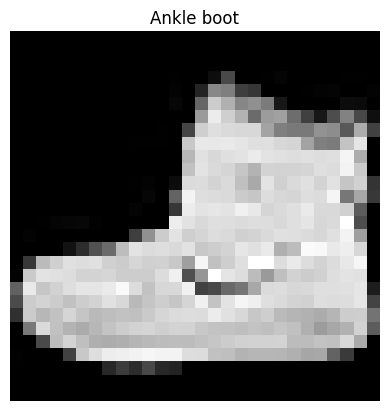

In [10]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

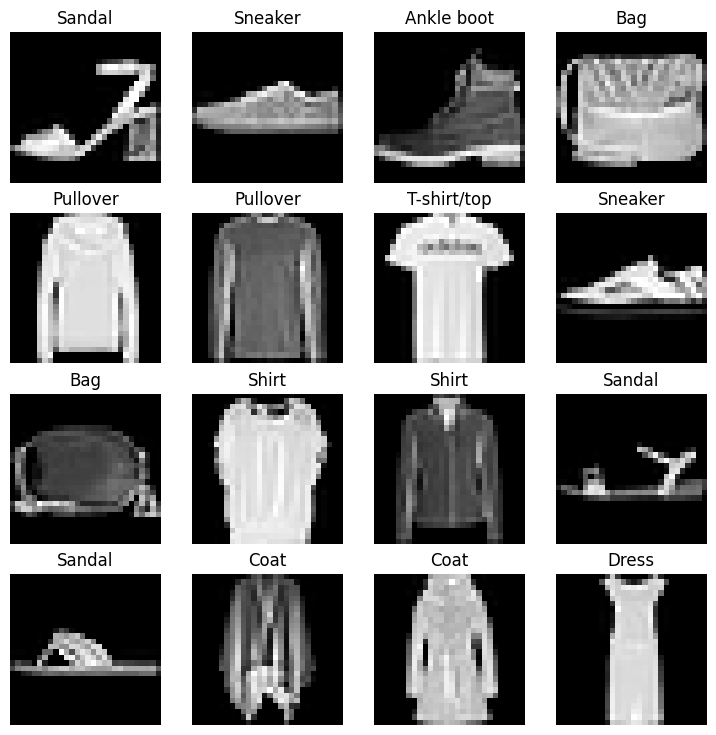

In [11]:
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);


## 2. Preparing DataLoader

We have to slice our dataset into batches because:

1. It is more computationally efficient, as in, your computing hardware may not be able to look (store in memory) at 60000 images in one hit.

2. It give our Neural Network more chances to improve (update its gradients per epoch).

In [178]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

test_dataloader = DataLoader(dataset=test_data,
                         batch_size=BATCH_SIZE,
                         shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21d94580890>,
 <torch.utils.data.dataloader.DataLoader at 0x21d95252a50>)

In [13]:
print(f"Length of train_DataLoader : {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_DataLoader : {len(test_dataloader)} batches of {BATCH_SIZE}...")

Length of train_DataLoader : 1875 batches of 32...
Length of test_DataLoader : 313 batches of 32...


In [14]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size : torch.Size([1, 28, 28])
Label : 4, label name : Coat


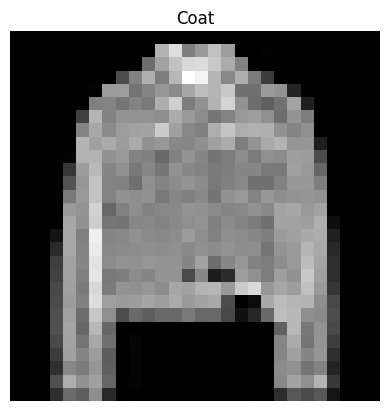

In [15]:
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size : {img.shape}")
print(f"Label : {label}, label name : {class_names[label]}")

## 3. Model 0: Building a baseline model

(Date - 20/May/2026)

A baseline model is a simple model you'll try and improve upon with subsequent models/experiments.<br>
In other words: start simply and add complexity when necessary.

In [16]:
flatten_model = nn.Flatten()

X = train_features_batch[0]
print(f"Shape without nn.Flatten() : {X.shape} -> [colour channels, height, width]")

output = flatten_model(X)
print(f"Shape by using nn.Flatten() : {output.shape} -> [colour channels , height * width] ")

Shape without nn.Flatten() : torch.Size([1, 28, 28]) -> [colour channels, height, width]
Shape by using nn.Flatten() : torch.Size([1, 784]) -> [colour channels , height * width] 


In [17]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units: int,
                 output_shape: int):

        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(), # Removing this layer may lead to shape mismatches
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
           
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape),
                                        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [18]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, 
                              hidden_units=10,
                              output_shape=len(class_names))

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [19]:
dummy_x = torch.randn([1,1,28,28])
dummy_output = model_0(dummy_x)
dummy_output, dummy_output.shape

(tensor([[-0.2228,  0.1477,  0.3137, -0.3110, -0.3713,  0.0156,  0.4363,  0.1060,
          -0.1604, -0.4388]], grad_fn=<AddmmBackward0>),
 torch.Size([1, 10]))

### 3.1 Setting up loss function, optimizer and evaluation metrics

* Loss function - `nn.ClassEntropyLoss()`
* Optimizer - `Adam`
* Evaluation metric - `Accuracy` (from torchmetrics)

In [20]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr = 0.1)

metric = Accuracy(task="multiclass", num_classes=10)

### 3.2 Creating function to time our experiments

Two of the main things you will often want to track are:
1. Model's performance (loss and accuracy)
2. How fast it runs.

In [21]:
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    
    """
    Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """

    total_time = end - start
    print(f"Train time on {device} : {total_time:.3f} seconds")
    return total_time

In [22]:
start_time = Timer()
end_time = Timer()
print_train_time(start=start_time, end=end_time, device = "cpu")

Train time on cpu : 0.000 seconds


4.949999993186793e-05

### 3.3 Creating a training loop and training the model on batches of data

(Date - 21/May/2026)

Batch size - 32<br>
Training batches - 1875<br>
Testing batches - 313

Process:
1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss per batch.
3. Loop through testing batches, perform testing steps, calculate the test loss per batch.
4. Print out what's happening.
5. Time it all (for fun).

In [23]:
torch.manual_seed(42)
train_time_start_on_cpu = Timer()

test_length = len(test_dataloader)
train_length = len(train_dataloader)
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n------")
    train_loss, train_acc = 0, 0
    
    for batch, (train_image, train_label) in enumerate(train_dataloader):
        model_0.train()

        train_pred = model_0(train_image)

        optimizer.zero_grad()

        loss = loss_fn(train_pred, train_label)
        train_loss += loss
        train_acc += metric(train_pred, train_label)

        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(train_image)}/{len(train_dataloader.dataset)} samples.")
    
    # calculate the average train loss and train accuracy
    avg_train_loss = train_loss / train_length
    avg_train_acc = (train_acc / train_length)*100

    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for test_image, test_label, in test_dataloader:
            test_pred = model_0(test_image)

            test_loss += loss_fn(test_pred, test_label)

            test_acc += metric(test_pred, test_label)
        
        avg_test_loss = test_loss / test_length
        avg_test_acc = (test_acc / test_length) * 100

    print(f"\nTrain loss: {avg_train_loss:.4f} | Train acc: {avg_train_acc:.3f}%| Test loss: {avg_test_loss:.4f} | Test acc: {avg_test_acc:.3f}%")

train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                            end=train_time_end_on_cpu, 
                                            device = str(next(model_0.parameters()).device))


  0%|                                                  | 0/3 [00:00<?, ?it/s]

Epoch : 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|████████████████▋                                 | 1/3 [00:19<00:38, 19.34s/it]


Train loss: 0.5904 | Train acc: 79.172%| Test loss: 0.5102 | Test acc: 82.039%
Epoch : 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|█████████████████████████████████▎                | 2/3 [00:32<00:15, 15.53s/it]


Train loss: 0.4743 | Train acc: 83.303%| Test loss: 0.5268 | Test acc: 81.679%
Epoch : 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████████████████████████████████████████████| 3/3 [00:44<00:00, 14.92s/it]


Train loss: 0.4537 | Train acc: 84.195%| Test loss: 0.5126 | Test acc: 82.997%
Train time on cpu : 44.807 seconds


## 4. Making predictions and get Model 0 results

In [24]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               accuracy_fn,
               device):
    
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    length = len(data_loader)
    loss, acc = 0,0 
    model.eval()
    with torch.inference_mode():
        for image, label in tqdm(data_loader):
            image, label = image.to(device), label.to(device)
            pred = model(image)

            loss += loss_fn(pred, label)
            acc += metric(pred, label)

        loss /= length
        acc /= length

        return {"model_name" : model.__class__.__name__,
                "model_loss" : loss.item(),
                "model_acc" : acc.item()*100}

In [25]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn=metric,
                             device=device)

model_0_results

100%|██████████████████████████████████████████████████| 313/313 [00:01<00:00, 190.96it/s]


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5125296115875244,
 'model_acc': 83.00718665122986}

## 5. Setting up device agnostic code

In [26]:
# Setting up device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 6. Model 1: Building a better model with non-linearity

In [27]:
# Creating a model with linear and non-linear layers

class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        
        super().__init__()
        self.layer_stack = nn.Sequential(

            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
                    nn.ReLU(),
                    nn.Linear(in_features=hidden_units,
                              out_features=output_shape),
                    # nn.ReLU()
                                        )
    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

next(model_1.parameters()).device, model_1.state_dict()

(device(type='cpu'),
 OrderedDict([('layer_stack.1.weight',
               tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                       [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                       [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                       ...,
                       [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                       [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                       [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
              ('layer_stack.1.bias',
               tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                        0.0018,  0.0163])),
              ('layer_stack.3.weight',
               tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                         0.2019,  0.2847],
                       [-0.1495,  0.1344, -0.

In [28]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                             lr = 0.1)

metric = Accuracy(task="multiclass", num_classes=10)

### 6.1 Functionizing our training loop

Let's create a function for:
* Training loop - train_step()
* Testing loop - test_step()

In [29]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    
    train_length = len(data_loader)
    train_loss, train_acc = 0,0 
    
    model.train()
    for batch, (train_image, train_label) in enumerate(data_loader):
        train_image, train_label = train_image.to(device), train_label.to(device)

        train_pred = model(train_image)


        optimizer.zero_grad()
        loss = loss_fn(train_pred, train_label)
        train_loss += loss
        train_acc += metric(train_pred, train_label)

        loss.backward()
        optimizer.step()

    # calculate the average train loss and train accuracy
    avg_train_loss = train_loss / train_length
    avg_train_acc = (train_acc / train_length)*100

    print(f"\nTrain loss: {avg_train_loss:.4f} | Train acc: {avg_train_acc:.3f}%")



In [30]:
def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    
    test_length = len(data_loader)
    test_loss, test_acc = 0, 0

    model.eval()
    with torch.inference_mode():
        for test_image, test_label, in data_loader:
            test_image, test_label = test_image.to(device), test_label.to(device)
            test_pred = model(test_image)

            test_loss += loss_fn(test_pred, test_label)

            test_acc += metric(test_pred, test_label)
        
        avg_test_loss = test_loss / test_length
        avg_test_acc = (test_acc / test_length) * 100

    print(f"\nTest loss: {avg_test_loss:.4f} | Test acc: {avg_test_acc:.3f}%")


In [96]:
torch.manual_seed(42)
train_time_start_on_cpu = Timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n--------")
    train_step(model=model_1,
           data_loader=train_dataloader,
           loss_fn=loss_fn,
           optimizer=optimizer,
           accuracy_fn=metric,
           device=device)
    
    

train_time_end_on_cpu = Timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu,
                                    end=train_time_end_on_cpu,
                                    device = device)

  0%|                                                  | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------


 33%|████████████████▋                                 | 1/3 [00:15<00:31, 15.61s/it]


Train loss: 0.4846 | Train acc: 82.852%
Epoch: 1
--------


 67%|█████████████████████████████████▎                | 2/3 [00:31<00:15, 15.84s/it]


Train loss: 0.4846 | Train acc: 82.852%
Epoch: 2
--------


100%|██████████████████████████████████████████████████| 3/3 [00:43<00:00, 14.37s/it]


Train loss: 0.4846 | Train acc: 82.852%
Train time on cpu : 43.111 seconds


In [32]:
test_time_start_on_cpu = Timer()
test_step(model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=metric,
        device=device)
test_time_end_on_cpu = Timer()
total_test_time = print_train_time(start=test_time_start_on_cpu,
                                   end=test_time_end_on_cpu,
                                   device = device)


Test loss: 0.4846 | Test acc: 82.852%
Train time on cpu : 8.632 seconds


(Date - 22/May/2026)

In [33]:
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn=metric,
                             device=device)

model_0_results

100%|██████████████████████████████████████████████████| 313/313 [00:01<00:00, 215.06it/s]


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5120583176612854,
 'model_acc': 83.02715420722961}

In [93]:
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn=metric,
                             device=device)

model_1_results

100%|██████████████████████████████████████████████████| 313/313 [00:02<00:00, 141.91it/s]


{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5392544269561768,
 'model_acc': 81.21006488800049}

## 7. Model 2: Building a Convolutional Neural Network (CNN)

(Date - 23/May/2026)

In [79]:
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture that replicates the TinyVGG
    model from CNN explainer website
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(

            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            
            nn.ReLU(),

            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
            stride=2) # stride = 2 by default
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),

            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
            stride=2) # stride = 2 by default
        )
        self.Classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(f"Output of conv block 1: {x.shape}")
        x = self.conv_block_2(x)
        # print(f"Output of conv block 2: {x.shape}")
        x = self.Classifier(x)
        # print(f"Output of Classifier: {x.shape}")
        return x

In [80]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(
            input_shape=1,
            hidden_units=10,
            output_shape=len(class_names)).to(device)

### 7.1 Stepping through `nn.conv2d()`

(Date - 24/May/2026)

In [81]:
torch.manual_seed(42)

images = torch.randn(size=(32,3,64,64))
test_image = images[0]

print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]") 
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [82]:
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=(3,3), # You can also write just 3.
                       stride=1,
                       padding=0
                       )

conv_layer(test_image).shape # ou might have to unsqueeze test_image if you are using older version of PyTorch.

torch.Size([10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [83]:
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=3)

test_image_through_conv = conv_layer(test_image)
print(f"Image Shape after going through conv_layer(): {test_image_through_conv.shape}")

test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Image shape after going through conv_layer() and max_pool() layer: {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Image Shape after going through conv_layer(): torch.Size([10, 62, 62])
Image shape after going through conv_layer() and max_pool() layer: torch.Size([10, 20, 20])


In [84]:
# Visualizing max pool

torch.manual_seed(42)

random_tensor = torch.randn(size=(1,1,2,2))
print(f"\nRandom Tensor: \n{random_tensor}")
print(f"\nRandom Tensor shape: \n{random_tensor.shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=2)

max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor : \n{max_pool_tensor}")
print(f"\nMax pool tensor shape : \n{max_pool_tensor.shape}")


Random Tensor: 
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])

Random Tensor shape: 
torch.Size([1, 1, 2, 2])

Max pool tensor : 
tensor([[[[0.3367]]]])

Max pool tensor shape : 
torch.Size([1, 1, 1, 1])


(Date - 25/May/2026)

In [85]:
image.shape

torch.Size([1, 28, 28])

In [86]:
rand_image_tensor = torch.randn(1,28,28)
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [87]:
model_2(rand_image_tensor.unsqueeze(0))

tensor([[ 0.0424, -0.0839,  0.0839, -0.0463,  0.0053,  0.0437,  0.0025,  0.0108,
         -0.0158, -0.0177]], grad_fn=<AddmmBackward0>)

### 7.3 Setting up a loss function and an optimizer

In [88]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr = 0.1)

metric = Accuracy(task="multiclass", num_classes=10)

### 7.4 Training our model_2

In [153]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_time_start_model_2 = Timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n----------")
    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=metric,
               device=device)
    
    test_step(model=model_2,
               data_loader=test_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=metric,
               device=device)

train_time_end_model_2 = Timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)

  0%|                                                  | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------

Train loss: 0.2918 | Train acc: 89.432%


 33%|████████████████▋                                 | 1/3 [00:45<01:31, 45.99s/it]


Test loss: 0.3055 | Test acc: 89.227%
Epoch: 1
----------

Train loss: 0.2813 | Train acc: 89.798%


 67%|█████████████████████████████████▎                | 2/3 [01:30<00:45, 45.02s/it]


Test loss: 0.3140 | Test acc: 88.648%
Epoch: 2
----------

Train loss: 0.2730 | Train acc: 90.110%


100%|██████████████████████████████████████████████████| 3/3 [02:16<00:00, 45.41s/it]


Test loss: 0.2988 | Test acc: 89.517%
Train time on cpu : 136.231 seconds


In [154]:
model_2_results = eval_model(
                model=model_2,
                data_loader=test_dataloader,
                loss_fn=loss_fn,
                accuracy_fn=metric,
                device=device
                            )       

model_2_results                            

100%|██████████████████████████████████████████████████| 313/313 [00:03<00:00, 88.10it/s]


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.2979933023452759,
 'model_acc': 89.54672813415527}

## 8. Comparing model results and training time

In [155]:
compare_results = pd.DataFrame([model_0_results,
                               model_1_results,
                               model_2_results])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.512058,83.027154
1,FashionMNISTModelV1,0.539254,81.210065
2,FashionMNISTModelV2,0.297993,89.546728


In [156]:
compare_results["Training time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,Training time
0,FashionMNISTModelV0,0.512058,83.027154,44.806538
1,FashionMNISTModelV1,0.539254,81.210065,43.110722
2,FashionMNISTModelV2,0.297993,89.546728,136.231399


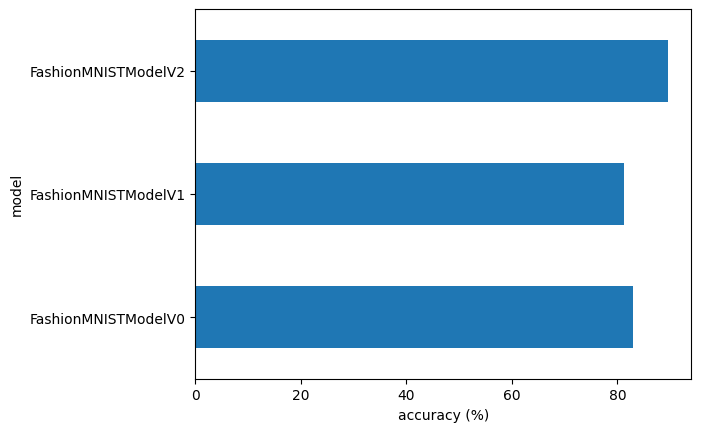

In [157]:
# Visualizing our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

## 9. Make and evaluate random predictions with the best model

In [158]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=1).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())
    
    return torch.stack(pred_probs)


In [159]:
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=12):
    test_samples.append(sample)
    test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Ankle boot')

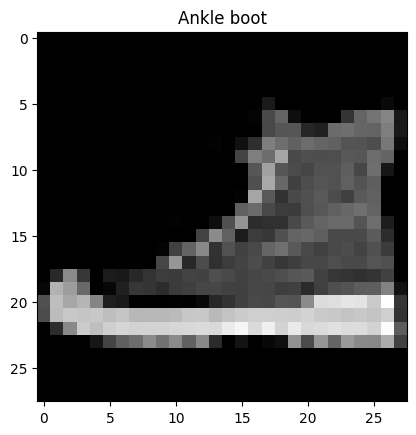

In [160]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [161]:
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

pred_probs[:2]

tensor([[1.4204e-06, 6.1030e-08, 2.7567e-07, 8.4387e-09, 4.1624e-10, 5.7867e-03,
         3.2333e-08, 1.4638e-02, 8.7839e-05, 9.7949e-01],
        [2.3422e-10, 4.8773e-09, 6.8619e-09, 1.0346e-08, 6.9638e-09, 2.9935e-06,
         4.3049e-11, 9.9999e-01, 7.8438e-07, 2.3481e-06]])

In [162]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([9, 7, 0, 4, 0, 5, 6, 2, 7, 8, 5, 8])

In [163]:
test_labels

[9, 7, 6, 4, 0, 5, 0, 2, 7, 8, 5, 8]

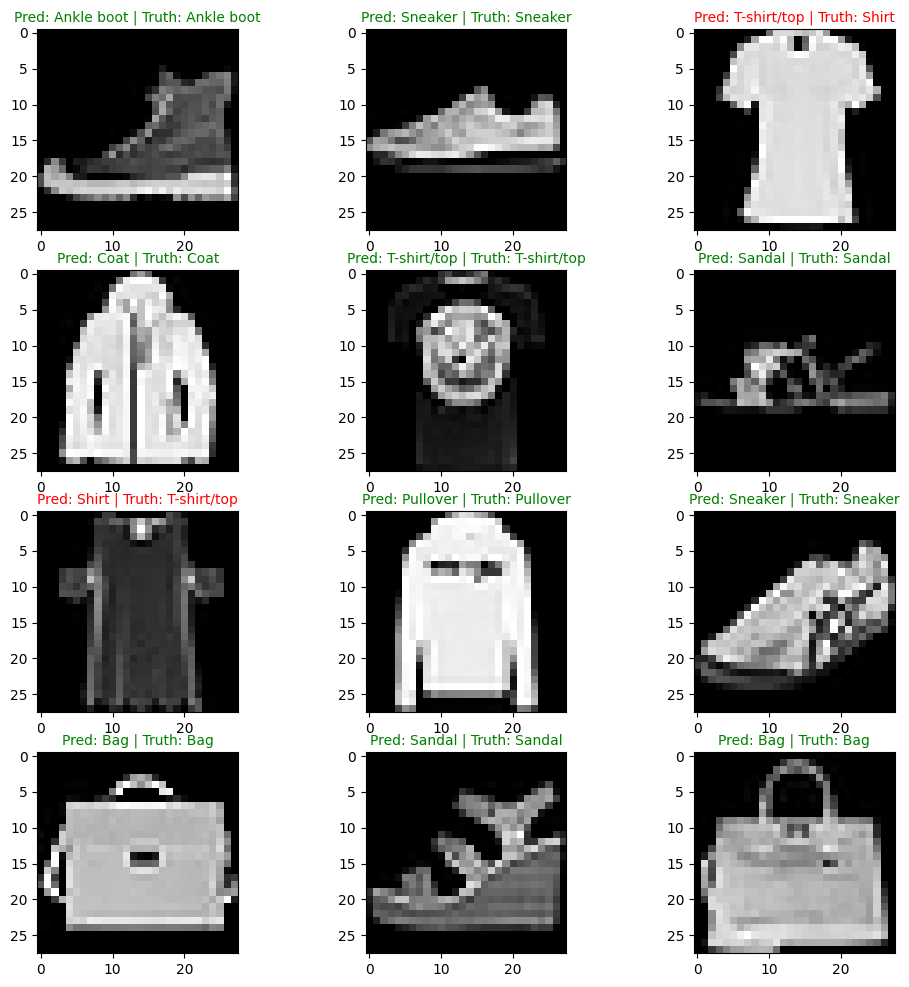

In [164]:
plt.figure(figsize=(12,12))
nrows = 4
ncols = 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")
    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")




## 10. Making a confusion matrix for further prediction evaluation

In [187]:
y_preds = []
model_2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        X, y = X.to(device), y.to(device)
        y_logit = model_2(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())

# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]


Making predictions...: 100%|██████████████████████████████████████████████████| 313/313 [00:04<00:00, 69.25it/s]


tensor([9, 2, 1, 1, 6, 1, 2, 6, 5, 7])

In [188]:
test_data.targets[:10]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [189]:
print(mlxtend.__version__) # The version should be 0.19 or higher (>=0.19)

0.24.0


In [190]:
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                         target = test_data.targets)

confmat_tensor

tensor([[886,   2,  23,  23,   4,   2,  48,   0,  12,   0],
        [  3, 984,   1,   9,   0,   0,   2,   0,   1,   0],
        [ 19,   1, 918,   6,  26,   0,  25,   0,   5,   0],
        [ 21,  11,  14, 903,  18,   0,  25,   0,   8,   0],
        [  1,   3, 144,  42, 751,   0,  54,   0,   5,   0],
        [  0,   0,   0,   1,   0, 957,   0,  32,   2,   8],
        [143,   2, 116,  32,  63,   0, 630,   0,  14,   0],
        [  0,   0,   0,   0,   0,   1,   0, 989,   0,  10],
        [  2,   1,   2,   2,   1,   1,   1,   3, 987,   0],
        [  0,   0,   0,   0,   0,   5,   0,  46,   0, 949]])

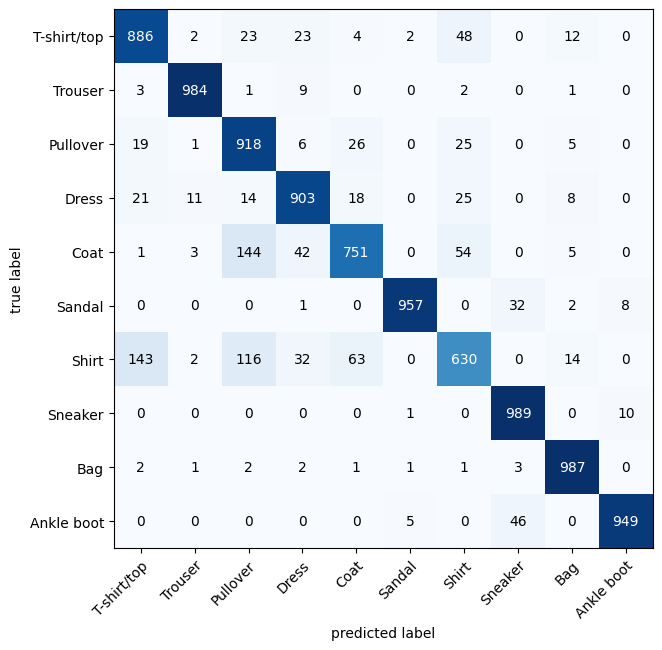

In [191]:
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                                class_names=class_names,
                                figsize=(16,7))

## 11. Saving and loading our best performing model

### 11.1 Saving our model

In [193]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

MODEL_NAME = "model_ipynb_28.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models\model_ipynb_28.pth


### 11.2 Loading our saved model

In [195]:
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (Classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [203]:
# Evaluating our loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=metric,
    device=device
)

loaded_model_2_results

100%|██████████████████████████████████████████████████| 313/313 [00:04<00:00, 72.59it/s]


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.298035591840744,
 'model_acc': 89.53673839569092}

In [204]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.2979933023452759,
 'model_acc': 89.54672813415527}

In [ ]:
# Check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-2
              )

tensor(True)